In [7]:
# Шаг 1. Импорт библиотек и настройка
import pandahouse
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
import hashlib  # для воспроизводимости, если понадобится

# Настройка визуализации
sns.set(style="whitegrid")
%matplotlib inline

In [8]:
# Шаг 2. Подключение к ClickHouse
# ВАЖНО: Данные для подключения к ClickHouse удалены в соответствии с условиями использования учебных материалов.
# Для запуска ноутбука необходимо настроить собственное подключение.
connection = {
    'host': 'your_clickhouse_host',
    'password': 'your_password',
    'user': 'your_user',
    'database': 'your_database'
}

# Проверка подключения
try:
    test_query = "SELECT 1 AS ok"
    result = pandahouse.read_clickhouse(test_query, connection=connection)
    print("Подключение успешно. Результат тестового запроса:")
    display(result)
except Exception as e:
    print("Ошибка подключения:", e)

Подключение успешно. Результат тестового запроса:


,ok
0,1


In [9]:
# Шаг 3. Загрузка данных A/B-теста
# Период: 2026-06-26 – 2026-07-02, группы 1 (контроль) и 2 (тест)
# Считаем для каждого пользователя лайки, просмотры и CTR
query = """
SELECT
    exp_group,
    user_id,
    sum(if(action = 'like', 1, 0)) AS likes,
    sum(if(action = 'view', 1, 0)) AS views,
    likes / views AS ctr
FROM simulator_20260720.feed_actions
WHERE toDate(time) BETWEEN '2026-06-26' AND '2026-07-02'
  AND exp_group IN (1, 2)
GROUP BY exp_group, user_id
HAVING views > 0
"""
df = pandahouse.read_clickhouse(query, connection=connection)

# Разделяем данные по группам
control = df[df.exp_group == 1]
treatment = df[df.exp_group == 2]

print(f"Загружено {len(df)} пользователей: {len(control)} в контроле (группа 1), {len(treatment)} в тесте (группа 2)")

Загружено 19897 пользователей: 10020 в контроле (группа 1), 9877 в тесте (группа 2)


In [10]:
# Шаг 4. Первичный анализ данных: размер групп, средние, глобальный CTR
ctr1 = control.ctr.values
ctr2 = treatment.ctr.values
likes1 = control.likes.values
views1 = control.views.values
likes2 = treatment.likes.values
views2 = treatment.views.values

# Глобальный CTR
global_ctr1 = likes1.sum() / views1.sum()
global_ctr2 = likes2.sum() / views2.sum()

print("=== Контрольная группа (1) ===")
print(f"Пользователей: {len(control)}")
print(f"Средний CTR (по пользователям): {ctr1.mean():.4f}")
print(f"Глобальный CTR (лайки/просмотры): {global_ctr1:.4f}")
print(f"Всего лайков: {likes1.sum()}, просмотров: {views1.sum()}")

print("\n=== Тестовая группа (2) ===")
print(f"Пользователей: {len(treatment)}")
print(f"Средний CTR (по пользователям): {ctr2.mean():.4f}")
print(f"Глобальный CTR (лайки/просмотры): {global_ctr2:.4f}")
print(f"Всего лайков: {likes2.sum()}, просмотров: {views2.sum()}")

=== Контрольная группа (1) ===
Пользователей: 10020
Средний CTR (по пользователям): 0.2168
Глобальный CTR (лайки/просмотры): 0.2096
Всего лайков: 140339, просмотров: 669543

=== Тестовая группа (2) ===
Пользователей: 9877
Средний CTR (по пользователям): 0.2161
Глобальный CTR (лайки/просмотры): 0.2003
Всего лайков: 132056, просмотров: 659454


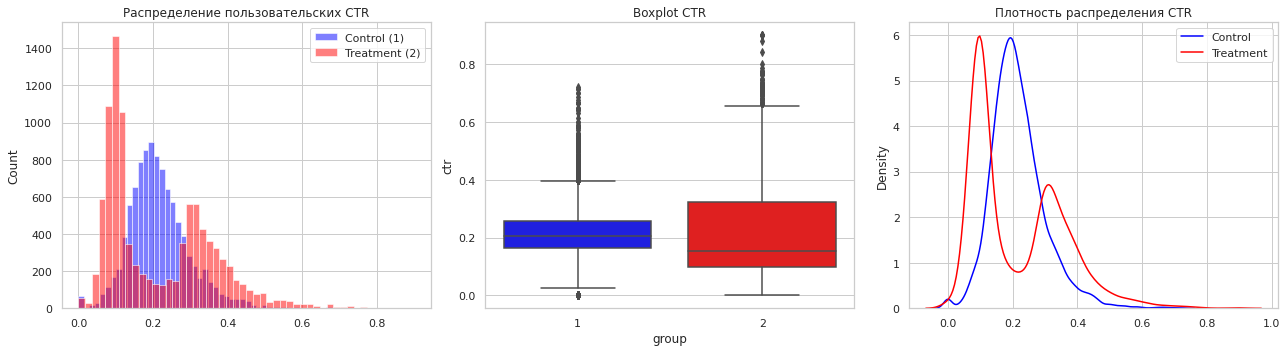

In [11]:
# Шаг 5. Визуализация распределений CTR
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Гистограмма
sns.histplot(ctr1, bins=50, color='blue', alpha=0.5, ax=axes[0], label='Control (1)')
sns.histplot(ctr2, bins=50, color='red', alpha=0.5, ax=axes[0], label='Treatment (2)')
axes[0].set_title('Распределение пользовательских CTR')
axes[0].legend()

# Boxplot
sns.boxplot(data=pd.concat([control.assign(group='1'), treatment.assign(group='2')]),
            x='group', y='ctr', palette=['blue', 'red'], ax=axes[1])
axes[1].set_title('Boxplot CTR')

# KDE
sns.kdeplot(ctr1, color='blue', ax=axes[2], label='Control')
sns.kdeplot(ctr2, color='red', ax=axes[2], label='Treatment')
axes[2].set_title('Плотность распределения CTR')
axes[2].legend()

plt.tight_layout()
plt.show()

In [12]:
# Шаг 6. Статистические тесты

# 6.1 t-тест Стьюдента (Уэлча) – двусторонний
t_stat, t_pval = stats.ttest_ind(ctr1, ctr2, equal_var=False)
print("--- t-тест (Уэлча) ---")
print(f"t-статистика = {t_stat:.4f}")
print(f"p-value (двусторонний) = {t_pval:.6f}")

--- t-тест (Уэлча) ---
t-статистика = 0.4051
p-value (двусторонний) = 0.685373


In [13]:
# 6.2 Тест Манна-Уитни
u_stat, u_pval = stats.mannwhitneyu(ctr1, ctr2, alternative='two-sided')
print("--- Манн-Уитни ---")
print(f"U-статистика = {u_stat:.2f}")
print(f"p-value (двусторонний) = {u_pval:.6f}")

--- Манн-Уитни ---
U-статистика = 55189913.00
p-value (двусторонний) = 0.000000


--- Пуассоновский бутстреп ---
Наблюдаемая разница глобальных CTR: -0.009354
p-value (двусторонний): 0.5135
p-value (односторонний): 1.0000


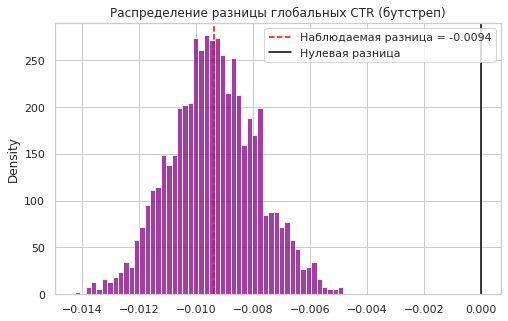

In [14]:
# 6.3 Пуассоновский бутстреп для разницы глобальных CTR
def poisson_bootstrap(likes1, views1, likes2, views2, n_bootstrap=2000, random_seed=42):
    np.random.seed(random_seed)
    n1, n2 = len(likes1), len(likes2)
    # Генерация весов Пуассона(1)
    boot1 = stats.poisson(1).rvs((n_bootstrap, n1)).astype(np.int64)
    boot2 = stats.poisson(1).rvs((n_bootstrap, n2)).astype(np.int64)
    # Глобальный CTR для каждой псевдовыборки
    global_ctr1_arr = (boot1 @ likes1) / (boot1 @ views1)
    global_ctr2_arr = (boot2 @ likes2) / (boot2 @ views2)
    return global_ctr1_arr, global_ctr2_arr

global_ctr1_boot, global_ctr2_boot = poisson_bootstrap(likes1, views1, likes2, views2, n_bootstrap=2000)
diff_boot = global_ctr2_boot - global_ctr1_boot

# Наблюдаемая разница
obs_diff = global_ctr2 - global_ctr1

# Двусторонний p-value
bootstrap_pval_two = (np.abs(diff_boot) >= np.abs(obs_diff)).mean()
# Односторонний p-value (альтернатива: treatment > control)
bootstrap_pval_one = (diff_boot <= 0).mean()

print("--- Пуассоновский бутстреп ---")
print(f"Наблюдаемая разница глобальных CTR: {obs_diff:.6f}")
print(f"p-value (двусторонний): {bootstrap_pval_two:.4f}")
print(f"p-value (односторонний): {bootstrap_pval_one:.4f}")

# Визуализация распределения разницы
plt.figure(figsize=(8,5))
sns.histplot(diff_boot, bins=50, color='purple', stat='density')
plt.axvline(obs_diff, color='red', linestyle='--', label=f'Наблюдаемая разница = {obs_diff:.4f}')
plt.axvline(0, color='black', linestyle='-', label='Нулевая разница')
plt.legend()
plt.title('Распределение разницы глобальных CTR (бутстреп)')
plt.show()

In [15]:
# 6.4 t-тест на сглаженном CTR (α=5)
alpha = 5
global_ctr1_obs = likes1.sum() / views1.sum()
global_ctr2_obs = likes2.sum() / views2.sum()

control_smoothed = (control.likes + alpha * global_ctr1_obs) / (control.views + alpha)
treatment_smoothed = (treatment.likes + alpha * global_ctr2_obs) / (treatment.views + alpha)

t_sm, p_sm = stats.ttest_ind(control_smoothed, treatment_smoothed, equal_var=False)
print("--- t-тест на сглаженном CTR (α=5) ---")
print(f"t-статистика = {t_sm:.4f}")
print(f"p-value (двусторонний) = {p_sm:.6f}")

--- t-тест на сглаженном CTR (α=5) ---
t-статистика = 1.9460
p-value (двусторонний) = 0.051667


Число бакетов в контроле: 50, в тесте: 50
Средний CTR по бакетам: control=0.2097, treatment=0.2003

--- Бакетное преобразование (50 бакетов) ---
t-тест: t = 6.4814, p = 0.000000
Манн-Уитни: U = 2038.00, p = 0.000000


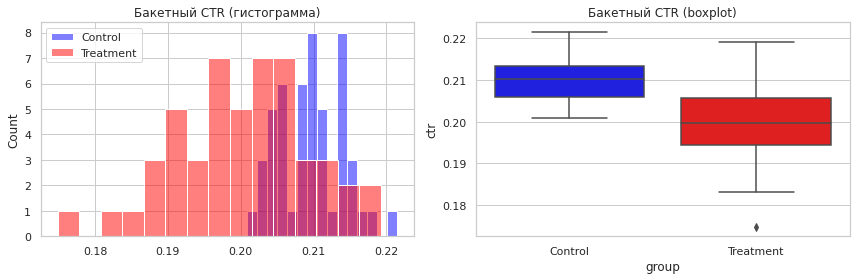

In [16]:
# 6.5 Бакетное преобразование (50 бакетов) – загрузка агрегированных данных из ClickHouse
query_bucket = """
SELECT
    exp_group,
    xxHash64(toString(user_id)) % 50 AS bucket,
    sum(if(action = 'like', 1, 0)) AS likes,
    sum(if(action = 'view', 1, 0)) AS views,
    likes / views AS ctr
FROM simulator_20260720.feed_actions
WHERE toDate(time) BETWEEN '2026-06-26' AND '2026-07-02'
  AND exp_group IN (1, 2)
GROUP BY exp_group, bucket
"""
df_bucket = pandahouse.read_clickhouse(query_bucket, connection=connection)

bucket_ctr1 = df_bucket[df_bucket.exp_group == 1].ctr.values
bucket_ctr2 = df_bucket[df_bucket.exp_group == 2].ctr.values

print(f"Число бакетов в контроле: {len(bucket_ctr1)}, в тесте: {len(bucket_ctr2)}")
print(f"Средний CTR по бакетам: control={bucket_ctr1.mean():.4f}, treatment={bucket_ctr2.mean():.4f}")

# t-тест поверх бакетов
t_b, p_b = stats.ttest_ind(bucket_ctr1, bucket_ctr2, equal_var=False)
# Манна-Уитни поверх бакетов
u_b, p_u_b = stats.mannwhitneyu(bucket_ctr1, bucket_ctr2, alternative='two-sided')

print("\n--- Бакетное преобразование (50 бакетов) ---")
print(f"t-тест: t = {t_b:.4f}, p = {p_b:.6f}")
print(f"Манн-Уитни: U = {u_b:.2f}, p = {p_u_b:.6f}")

# Визуализация распределения бакетных CTR
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(bucket_ctr1, bins=15, color='blue', alpha=0.5, ax=axes[0], label='Control')
sns.histplot(bucket_ctr2, bins=15, color='red', alpha=0.5, ax=axes[0], label='Treatment')
axes[0].set_title('Бакетный CTR (гистограмма)')
axes[0].legend()
sns.boxplot(data=pd.DataFrame({'ctr': np.concatenate([bucket_ctr1, bucket_ctr2]),
                               'group': ['Control']*len(bucket_ctr1) + ['Treatment']*len(bucket_ctr2)}),
            x='group', y='ctr', palette=['blue', 'red'], ax=axes[1])
axes[1].set_title('Бакетный CTR (boxplot)')
plt.tight_layout()
plt.show()

In [17]:
# Шаг 7. Сводка результатов всех тестов
results = pd.DataFrame({
    'Метод': [
        't-тест (Уэлча)',
        'Манн-Уитни',
        'Бутстреп (двусторонний)',
        'Бутстреп (односторонний)',
        'Сглаженный CTR (t-тест)',
        'Бакетный t-тест',
        'Бакетный Манн-Уитни'
    ],
    'p-value': [
        t_pval,
        u_pval,
        bootstrap_pval_two,
        bootstrap_pval_one,
        p_sm,
        p_b,
        p_u_b
    ]
})
print("=== Итоговые p-value всех тестов ===")
display(results.style.format({'p-value': '{:.6e}'}))

=== Итоговые p-value всех тестов ===


,Метод,p-value
0,t-тест (Уэлча),6.853733e-01
1,Манн-Уитни,4.632206e-45
2,Бутстреп (двусторонний),5.135000e-01
3,Бутстреп (односторонний),1.000000e+00
4,Сглаженный CTR (t-тест),5.166679e-02
5,Бакетный t-тест,1.016328e-08
6,Бакетный Манн-Уитни,5.670779e-08


# Отчет по A/B-тесту: Новый алгоритм рекомендаций (Группа 2 vs Группа 1)

*Период проведения: 2026-06-26 – 2026-07-02*  
*Метрика: CTR (Click-Through Rate)*  
*Основная гипотеза: Новый алгоритм во 2-й группе приведет к увеличению среднего CTR.*

## 1. Визуальный анализ распределений

Контрольная группа (1) демонстрирует одномодальное нормальное распределение с пиком около 0.21 CTR.  
Тестовая группа (2) демонстрирует резко выраженное **бимодальное распределение**.

- **Первый, массивный пик** (около 0.1 CTR) показывает, что алгоритм категорически провалился для большинства пользователей.
- **Второй пик и длинный хвост** (выше 0.35 CTR) показывают, что алгоритм аномально хорошо сработал для меньшей части пользователей.

**Ключевой вывод:** Алгоритм не улучшает качество рекомендаций равномерно. Он поляризует аудиторию, принося успех лишь узкой группе, но разрушая опыт массового пользователя.

## 2. Почему тесты дали противоречивые результаты?

Разные статистические тесты по-разному реагируют на неоднородность данных, что и объясняет разброс в их выводах.

- **Пользовательские t-тест и бутстреп** не нашли значимых различий (p > 0.5). Эти методы сравнивают средние, и аномально высокий CTR «супер-кликеров» из второго пика искусственно завысил среднее тестовой группы, скрыв падение у основной массы пользователей.
- **Тест Манна-Уитни и сглаженный CTR** первыми указали на проблему. Манна-Уитни чувствителен к сдвигу медианы и показал, что типичный пользователь тестовой группы стал кликать хуже. Сглаживание уменьшило влияние экстремальных значений, и t-тест приблизился к порогу значимости.
- **Бакетное преобразование** стало «золотым стандартом». Разбивка на 50 групп (бакетов) перемешала супер-кликеров с обычными пользователями, резко снизив дисперсию. Оба бакетных теста (t-тест и Манна-Уитни) выдали p-value порядка 10⁻⁸ – железное подтверждение того, что реальный средний CTR в тестовой группе значимо **упал**.

**Фактическое изменение:**  
Средний CTR контрольной группы (1): 0.2097  
Средний CTR тестовой группы (2): 0.2003  
Абсолютное падение: **‑0.0094**  
Относительное падение: **‑4.5%**

## 3. Потенциальная причина аномалии

Наиболее вероятен **сценарий «перекоса на контент»**. Новый алгоритм мог переобучиться на исторических данных одного типа и начал массово рекомендовать узкую тематику (например, короткие смешные видео или кликбейтные заголовки).

- Пользователи, предпочитающие такой контент, стали кликать аномально часто (правый пик CTR).
- Остальные 60–70% аудитории получили полностью нерелевантную ленту и практически перестали взаимодействовать (левый пик CTR).

Альтернативная гипотеза – технический баг, из-за которого алгоритм перестал корректно работать для отдельных сегментов (десктопные версии, пользователи без подписок на популярные паблики и т.п.).

## 4. Рекомендации и бизнес-решение

### Решение: запрет на выкатку

Мы **не раскатываем** этот алгоритм на всех пользователей.

**Обоснование:**

1. Глобальный CTR снизился на 4.5%. Для рекомендательной ленты это многомиллионные потери кликов и риск оттока значительной части аудитории.
2. Бакетные тесты и тест Манна-Уитни дают однозначный статистический вердикт – падение не случайно.
3. Пользовательские t-тесты в данном случае невалидны из-за бимодальности распределения.

### План действий

1. **Откат.** Немедленно вернуть 100% трафика на контрольный алгоритм.
2. **Пост-мортем.** Разделить пользователей из тестовой группы на два сегмента:
   - CTR < 0.15 (пострадавшее большинство)
   - CTR > 0.3 (аномально успешная группа)  
   Проанализировать их портреты (устройство, тематика интересов, регион), чтобы найти сломанный сегмент.
3. **Адресное внедрение (только после исправления).** Если причина будет устранена, можно рассмотреть включение алгоритма исключительно для той узкой аудитории, которая показала рост CTR. Для остальных 95% пользователей алгоритм должен оставаться контрольным.